In [1]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow import keras

import numpy as np

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Train features set shape: {X_train.shape}")
print(f"Train labels set shape: {y_train.shape}")
print(f"Test features set shape: {X_test.shape}")
print(f"Test labels set shape: {y_test.shape}")

Train features set shape: (60000, 28, 28)
Train labels set shape: (60000,)
Test features set shape: (10000, 28, 28)
Test labels set shape: (10000,)


In [3]:
print(f"Pixels values range - Train set: [{X_train.min()}, {X_train.max()}]")
print(f"Pixels values range - Test set: [{X_test.min()}, {X_test.max()}]")

# Normalization: Divide pixels values by 255
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0
print(
    f"\nPixels values range - Train set normalize: [{X_train_norm.min()}, {X_train_norm.max()}]"
)
print(
    f"Pixels values range - Test set normalize: [{X_test_norm.min()}, {X_test_norm.max()}]"
)

# Reshape: (n, w, h) -> (n, w, h, 1)
# 1 for white/black
# 3 for RGB
_, w, h = X_train.shape
X_train_cnn = X_train_norm.reshape(-1, w, h, 1)
X_test_cnn = X_test_norm.reshape(-1, w, h, 1)
print(f"\nTrain set cnn shape: {X_train_cnn.shape}")
print(f"Test set cnn shape: {X_test_cnn.shape}")

# Encode labels: 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)
print("\nLabels encoded:")
for label in np.unique(y_train):
    idx = np.where(y_train == label)[0][0]
    print(f"{label} ---> {y_train_onehot[idx]}")

Pixels values range - Train set: [0, 255]
Pixels values range - Test set: [0, 255]

Pixels values range - Train set normalize: [0.0, 1.0]
Pixels values range - Test set normalize: [0.0, 1.0]

Train set cnn shape: (60000, 28, 28, 1)
Test set cnn shape: (10000, 28, 28, 1)

Labels encoded:
0 ---> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1 ---> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
2 ---> [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
3 ---> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
4 ---> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
5 ---> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
6 ---> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
7 ---> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
8 ---> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
9 ---> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [4]:
def create_model() -> keras.Sequential:
    model = keras.Sequential(
        [
            keras.layers.Input(shape=(w, h, 1), name="input"),
            keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
            keras.layers.MaxPooling2D((2, 2), name="pool1"),
            keras.layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
            keras.layers.MaxPooling2D((2, 2), name="pool2"),
            keras.layers.Flatten(name="flatten"),
            keras.layers.Dense(128, activation="relu", name="dense1"),
            keras.layers.Dense(64, activation="relu", name="dense2"),
            keras.layers.Dense(32, activation="relu", name="dense3"),
            keras.layers.Dense(10, activation="softmax", name="output"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,410 (915.66 KB)

 Trainable params: 234,410 (915.66 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def create_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr():
    return keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train_cnn,
    y_train_onehot,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9314 - loss: 0.2242 - val_accuracy: 0.9765 - val_loss: 0.0815 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9809 - loss: 0.0614 - val_accuracy: 0.9843 - val_loss: 0.0547 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9869 - loss: 0.0428 - val_accuracy: 0.9872 - val_loss: 0.0482 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9872 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9920 - loss: 0.0253 - val_accuracy: 0.9877 - val_loss: 0.0456 - learning_rate: 0.0010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9938 - loss: 0.0186 - val_accuracy: 0.9884 - val_loss: 0.0467 - learning_rate: 0.0010
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9948 - loss: 0.0158 - 

In [6]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_onehot, verbose=1)

print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9917 - loss: 0.0305
Test loss: 0.03047238104045391
Test accuracy: 0.9916999936103821


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


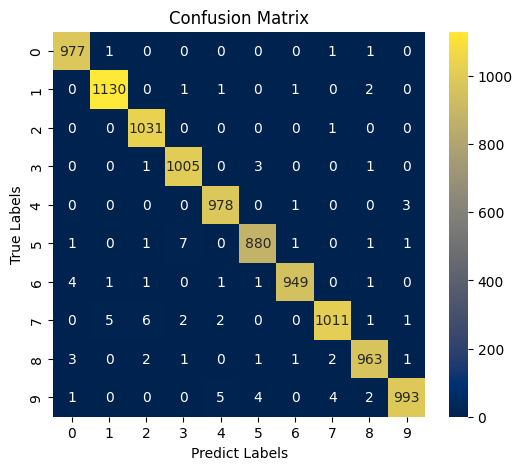

In [7]:
predictions = model.predict(X_test_cnn)
predicted_classes = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()